# LSSTCam tracklets and scoring

This notebook selects dense fields using the actual Sorcha LSSTCam visit geometry rather than a circular or rectangular sky cut. Every detection is joined to its Rubin pointing-database visit and revalidated against Sorcha's built-in 189-detector footprint, including chip gaps and the configured 2 arcsec edge exclusion.

The analysis starts with the densest night-61642 visit pair, **Field A**, then expands by tracklet density to spatially distinct camera fields until the identity-matched sample contains at least 75 NEOs and 75 non-NEOs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from lsstcam_tracklets_scoring import (
    analysis_audit,
    plot_camera_geometry,
    plot_dense_precision_recall,
    plot_dense_roc,
    plot_field_a,
    plot_selected_field_sky,
    plot_zero_diagnostics,
    prepare_analysis,
    select_dense_fields,
)

NIGHT = 61642
ROOT = Path.cwd().resolve()
POINTING_DB = ROOT.parent / 'baseline_v5.0.0_2yrs.db'
print(f'Notebook root: {ROOT}')
print(f'Pointing database: {POINTING_DB}')

Notebook root: /Users/devanshisingh/Downloads/research/NEO_probability/neomod
Pointing database: /Users/devanshisingh/Downloads/research/NEO_probability/baseline_v5.0.0_2yrs.db


## 1. Load data, reconstruct visits, and validate detections

Sorcha reports each detection time at the exposure midpoint. The join therefore compares `mjd0_tai` and `mjd1_tai` with `observationStartMJD + visitTime/2`, checks that the filter agrees, and requires a sub-0.01-second match. Both detections are then tested against their own visit's rotated LSSTCam footprint.

In [2]:
data = prepare_analysis(ROOT, night=NIGHT)
display(analysis_audit(data).to_frame())

assert data.sorcha.on_sensor0.all()
assert data.sorcha.on_sensor1.all()
assert data.sorcha.visit_match_error_s0.max() < 0.01
assert data.sorcha.visit_match_error_s1.max() < 0.01

,value
night,6.164200e+04
pointing visits loaded,1.154000e+03
Sorcha tracklets,4.316000e+03
identity matches,1.762000e+03
matched NEOs,7.940000e+02
unique visit pairs,9.480000e+02
maximum visit-match error (s),6.286427e-07
detections on active silicon,8.632000e+03
active detectors,1.890000e+02
"active focal-plane area (deg^2, tangent plane)",9.494223e+00


## 2. Exact LSSTCam focal-plane geometry

The detector polygons below are loaded directly by Sorcha's `Footprint()` class. The chip gaps and corner truncations are data, not a hand-drawn camera silhouette. The area reported here is the sum of detector areas in the tangent plane.

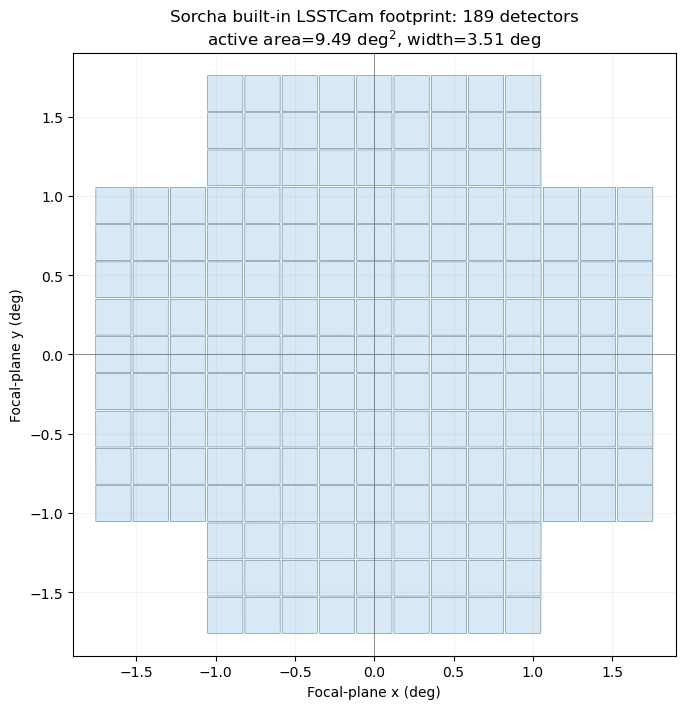

In [3]:
fig = plot_camera_geometry(data)
plt.show()

## 3. Field A and the dense-field sample

A field is the actual pair of visits that generated a tracklet. Candidate pairs are ranked only by total Sorcha tracklet count. Starting from Field A, a candidate is retained when its center is at least 3.5 degrees from every previously selected center. Selection stops when the cumulative identity-matched sample reaches at least 75 benchmark-truth NEOs and 75 non-NEOs. Population labels and scores never enter the ranking.

In [4]:
selected, selected_tracklets, selected_matched = select_dense_fields(data)
field_a = selected.iloc[0]
field_a_tracklets = selected_tracklets[selected_tracklets.field_label.eq('A')]
field_a_matched = selected_matched[selected_matched.field_label.eq('A')]

print(f'Selected {len(selected)} fields')
print(f'All selected Sorcha tracklets: {len(selected_tracklets)}')
print(f'Identity matches: {len(selected_matched)}')
print(f"Matched truth: {(selected_matched.population_bench == 'NEO').sum()} NEO / {(selected_matched.population_bench != 'NEO').sum()} non-NEO")
print(f'Field A: {field_a.field_key}, {len(field_a_tracklets)} tracklets, {len(field_a_matched)} identity matches')
display(field_a_tracklets.population.value_counts().rename('Field A Sorcha count').to_frame())
display(field_a_matched.population_bench.value_counts().rename('Field A matched truth').to_frame())
display(selected[[
    'field_label', 'field_key', 'n_tracklets', 'fieldRA', 'fieldDec',
    'n_matched', 'n_neo', 'n_nonneo', 'cum_neo', 'cum_nonneo'
]])

assert selected.n_neo.sum() >= 75
assert selected.n_nonneo.sum() >= 75
assert selected_tracklets.tracklet_id.is_unique
assert selected_matched.ObjID.is_unique

Selected 27 fields
All selected Sorcha tracklets: 547
Identity matches: 199
Matched truth: 75 NEO / 124 non-NEO
Field A: 373765-373817, 25 tracklets, 9 identity matches


,Field A Sorcha count
population,
MBA,19
NEO,5
TNO,1


,Field A matched truth
population_bench,
NEO,5
MBA,4


,field_label,field_key,n_tracklets,fieldRA,fieldDec,n_matched,n_neo,n_nonneo,cum_neo,cum_nonneo
0,A,373765-373817,25,315.682518,-13.277114,9,5,4,5,4
1,B,374006-374058,24,347.661526,-8.854711,8,4,4,9,8
2,C,374107-374159,24,10.459801,1.945125,8,3,5,12,13
3,D,374108-374160,24,5.612436,2.863203,9,5,4,17,17
4,E,373658-373710,23,270.458664,-26.631080,10,1,9,18,26
5,F,373659-373711,23,272.320612,-21.213524,8,3,5,21,31
6,G,373788-373840,23,325.934811,-4.209116,8,4,4,25,35
7,H,373905-373961,23,308.815162,-22.414323,10,3,7,28,42
8,I,373910-373966,23,317.513085,-17.845165,7,3,4,31,46
9,J,373776-373828,21,338.532729,-13.867824,6,2,4,33,50


## 4. Field A: camera footprints and tracklets

Blue detector outlines show the first visit; orange dashed outlines show the second. The left panel uses benchmark population truth where an identity match exists and gray for unmatched Sorcha tracklets. The right panel colors the same tracklets by Sorcha's V-band VDP score.

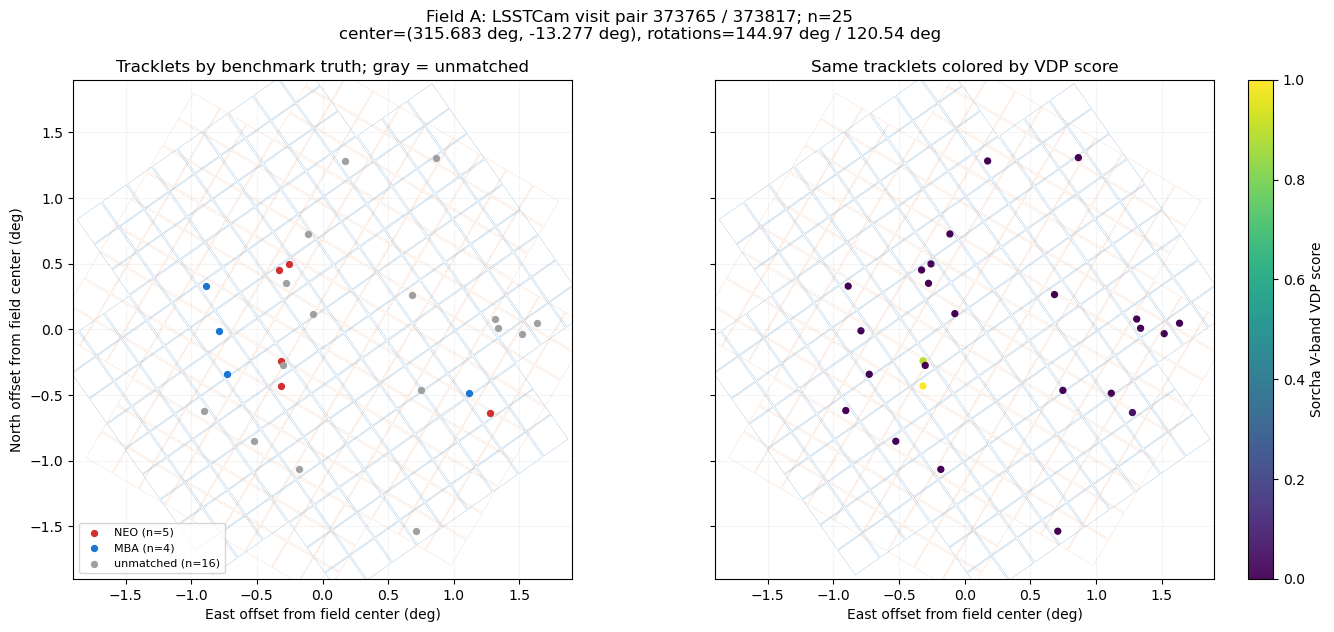

In [5]:
fig = plot_field_a(data, selected)
plt.show()

## 5. More dense fields

This sky view shows the exact first-visit detector polygons for every selected field. Labels follow density order: A is the densest, then B, C, and so on. The full candidate and membership tables are saved under `outputs/`.

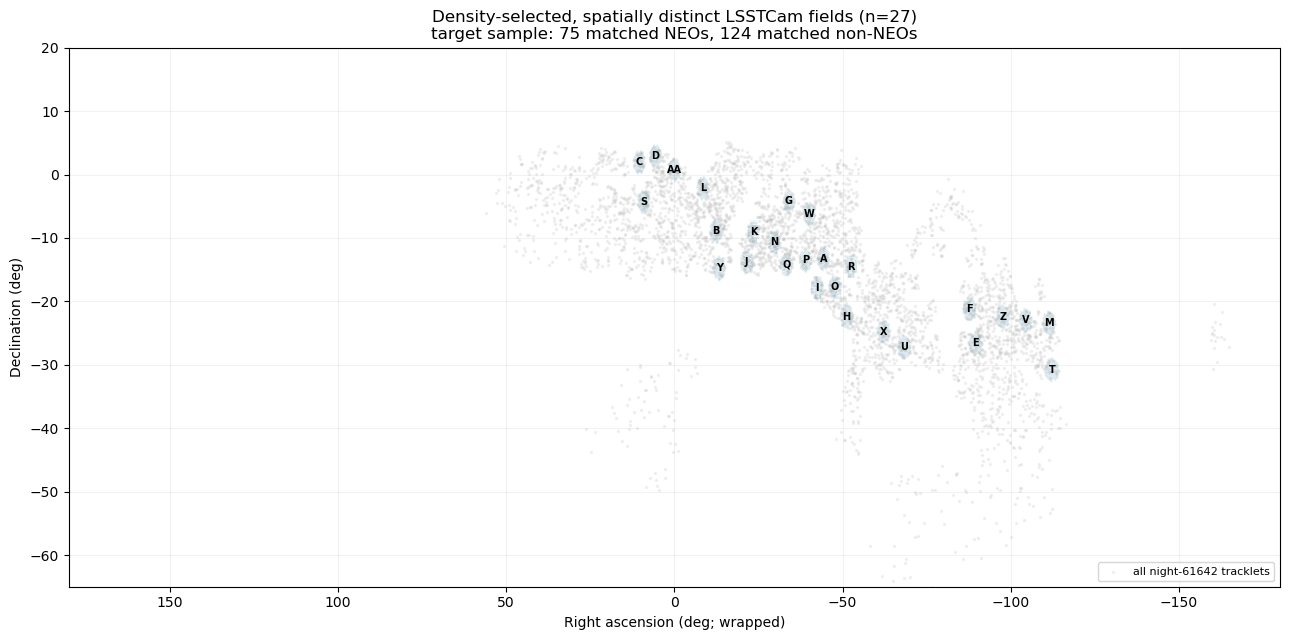

In [6]:
fig = plot_selected_field_sky(data, selected)
plt.show()

## 6. VDP versus digest2: completeness and contamination

These are precision-recall-derived operating curves, despite the historical `ROC` naming in earlier notebooks. Both panels use the same identity-matched objects and benchmark population truth. The shaded intervals are 16th-84th percentiles from a camera-field cluster bootstrap.

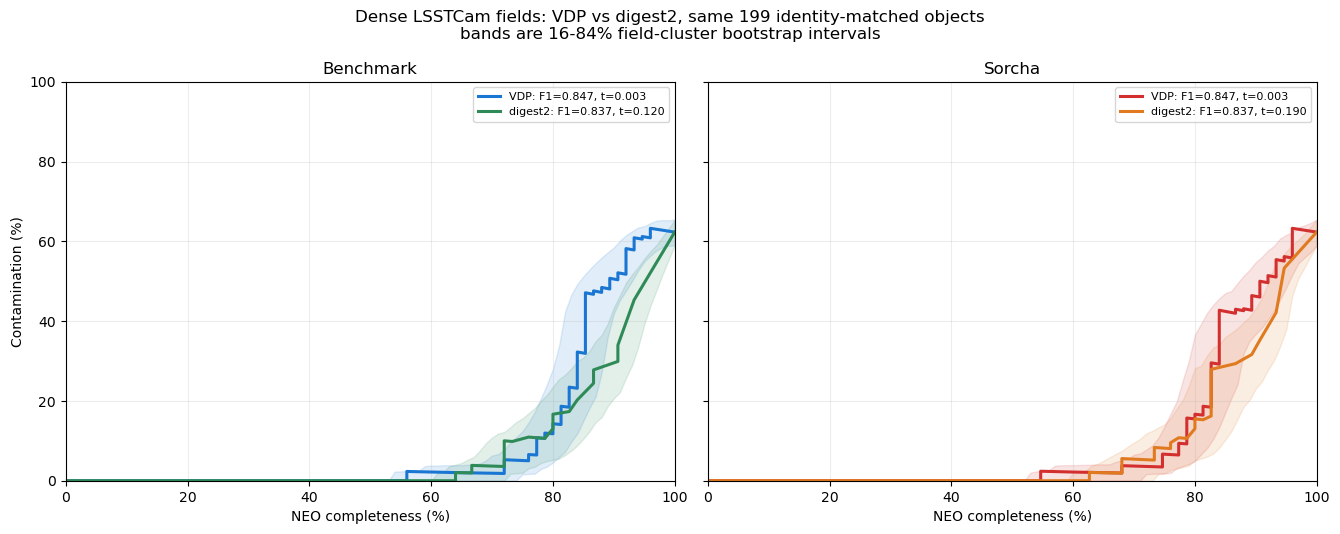

In [7]:
fig = plot_dense_precision_recall(data, selected_matched)
plt.show()

## 7. Conventional ROC and AUC

For clarity, this separate figure uses the conventional true-positive-rate versus false-positive-rate definition of ROC.

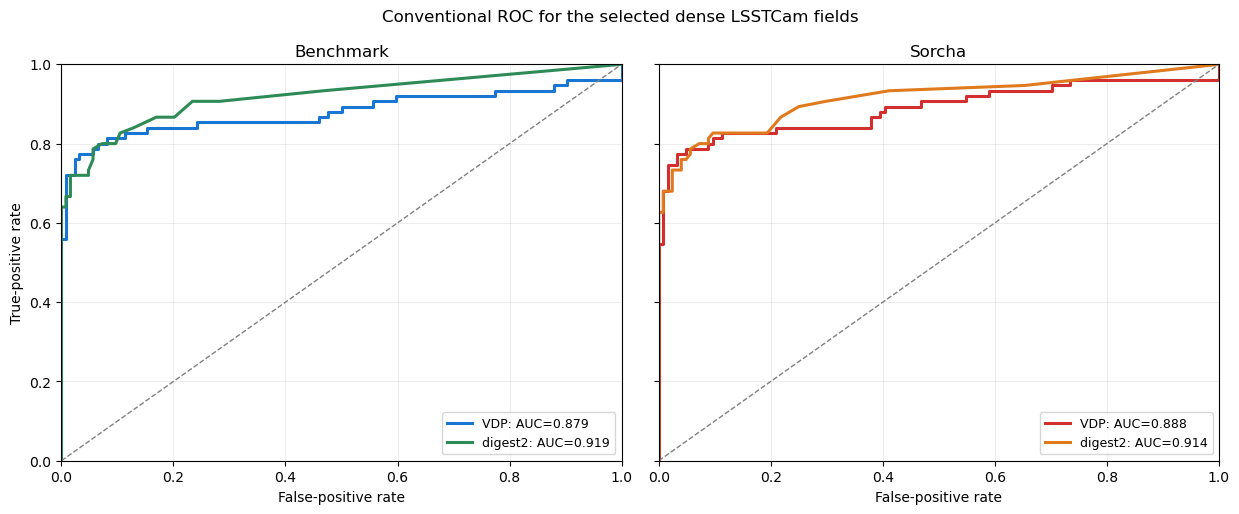

In [8]:
fig = plot_dense_roc(data, selected_matched)
plt.show()

## 8. Paired scores and the Sorcha VDP zero cohort

The first panel compares benchmark and Sorcha VDP object by object. The second asks whether digest2 assigns appreciable probability to objects for which Sorcha VDP returns exactly zero.

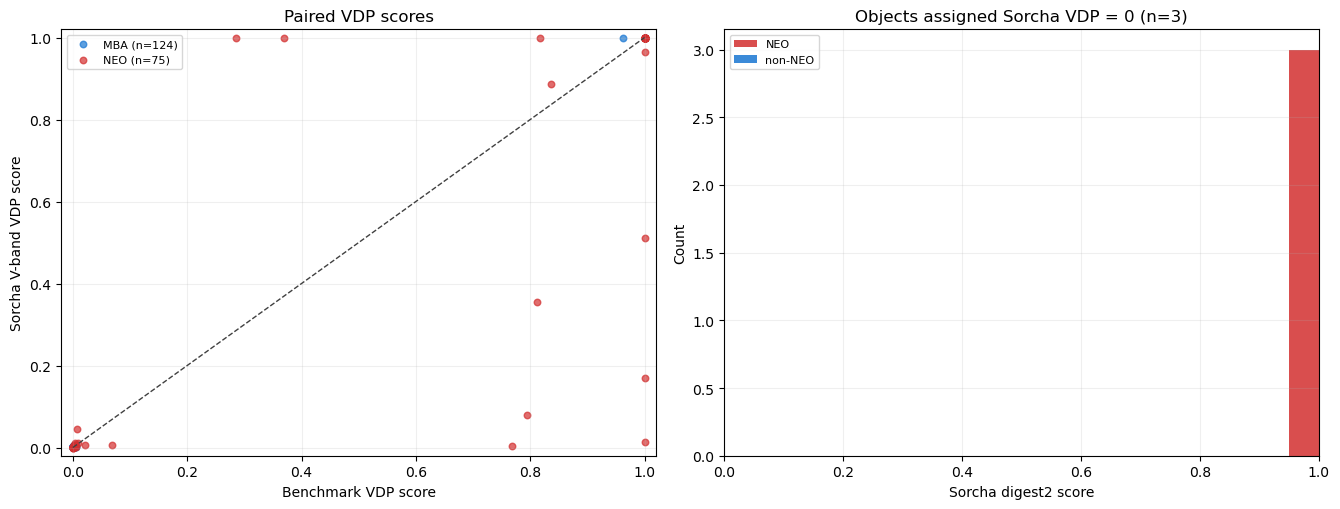

,n,digest2_median,digest2_high
population_bench,,,
NEO,3,1.0,3


In [9]:
fig = plot_zero_diagnostics(data, selected_matched)
plt.show()

zero = selected_matched.P_NEO_vdp_Vband.eq(0)
zero_summary = selected_matched.loc[zero].groupby('population_bench').agg(
    n=('ObjID', 'size'),
    digest2_median=('P_NEO_d2', 'median'),
    digest2_high=('P_NEO_d2', lambda values: values.gt(0.5).sum()),
)
display(zero_summary)

## Outputs

Figures are saved as `Figures/LSSTcam_01_...png` through `Figures/LSSTcam_06_...png`. Reproducibility tables are saved as:

- `outputs/LSSTcam_top30_field_candidates.csv`
- `outputs/LSSTcam_selected_fields.csv`
- `outputs/LSSTcam_selected_tracklets.csv`

Field A remains a descriptive case study because its identity-matched sample is small. Statistical comparisons use the prespecified multi-field aggregate.